## Анализ торгов нефтепродуктами на СПбМТСБ

Загрузка, подготовка и разметка данных.

In [135]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

FILE = 'spb_exchange_raw_2026.xlsx'
df = pd.read_excel(FILE, sheet_name='Данные СПбМТСБ 2026')


df['Дата торгов'] = pd.to_datetime(df['Дата торгов'])

num_cols = [
    'Лучший Ask (руб/т)', 'Лучший Bid (руб/т)', 'Цена закрытия (руб/т)',
    'Средневзв. цена VWAP (руб/т)', 'VWAP расч. (руб/т)', 'Объём (т)', 'Объём (руб)',
    'Число сделок', 'Число сделок на понижение', 'Объём на понижение (т)',
    'Объём на понижение (руб)', 'Изм. VWAP (руб/т)', 'Изм. VWAP (%)',
    'Изм. цены закр. (руб/т)', 'Изм. цены закр. (%)',
    'Макс. за 52 нед. (руб/т)', 'Мин. за 52 нед. (руб/т)'
]


for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors ='coerce')

df['Спред (руб/т)'] = df['Лучший Ask (руб/т)'] - df['Лучший Bid (руб/т)']
df['Спред (%)'] = df['Спред (руб/т)'] / df['Средневзв. цена VWAP (руб/т)'] * 100


df['Есть сделка'] = df['Объём (т)'].fillna(0) > 0

print(f'Записей с реальными сделками: {df["Есть сделка"].sum():,} из {len(df):,} '
      f'({df["Есть сделка"].mean():.0%})')

GPN_PLANTS = {
    'Омский НПЗ': 'Омск',
    'Московский НПЗ': 'Москва',
    'Ярославнефтеоргсинтез': 'Ярославль',
}

df['Площадка ГПН'] = df['НПЗ'].map(GPN_PLANTS)

df['Это ГПН'] = df['НПЗ'].isin(GPN)

df['Группа компании'] = np.where(df['Это ГПН'], 'Газпром нефть — ' + df['НПЗ'], 'Рынок (конкуренты)')

trades = df[df['Есть сделка']].copy()          # только записи с реальными сделками — для объёмов/цен
quotes = df.copy()                              # все записи (включая котировки без сделок) — для спредов

print(f'Сделок с объёмом > 0: {len(trades):,}')
print(f'Из них ГПН: {trades["Это ГПН"].sum():,} ({trades["Это ГПН"].mean():.1%})')

Записей с реальными сделками: 11,969 из 30,032 (40%)
Сделок с объёмом > 0: 11,969
Из них ГПН: 1,387 (11.6%)


## Доля рынка нефтяных компаний по объёму торгов (динамика по неделям)

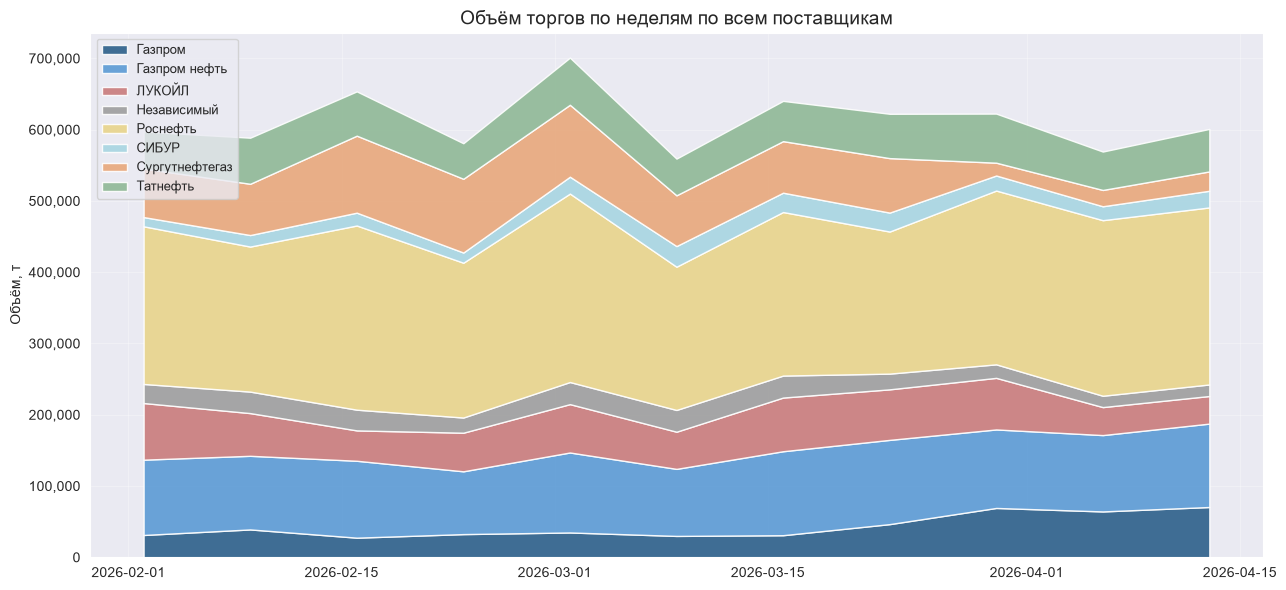

In [131]:
trades['Неделя'] = trades['Дата торгов'].dt.to_period('W').apply(lambda p: p.start_time)
weekly = trades.replace({'Роснефть / Башнефть':'Роснефть',
                         'Независимый / Газпром нефть':'Газпром нефть',
                         'Газпром нефть / Роснефть (Славнефть)':'Газпром нефть'}).groupby(['Неделя', 'Поставщик'])['Объём (т)'].sum().unstack(fill_value=0)


weekly_share = weekly.div(weekly.sum(axis = 1), axis = 0) * 100


companies = weekly.columns
colors = ['#2C5F8A', '#5B9BD5', '#C97B7B', '#9E9E9E', '#E8D48B', '#A8D5E2', '#E8A87C', '#8FB996']

# === ГРАФИК 1: Объём торгов (Stackplot) ===
fig1, ax1 = plt.subplots(figsize=(13, 6))

ax1.stackplot(
    weekly.index, 
    weekly.fillna(0).values.T,
    labels=companies, 
    colors=colors, 
    alpha=0.9
)
ax1.set_title('Объём торгов по неделям по всем поставщикам', fontsize=14)
ax1.set_ylabel('Объём, т')
ax1.legend(loc='upper left', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

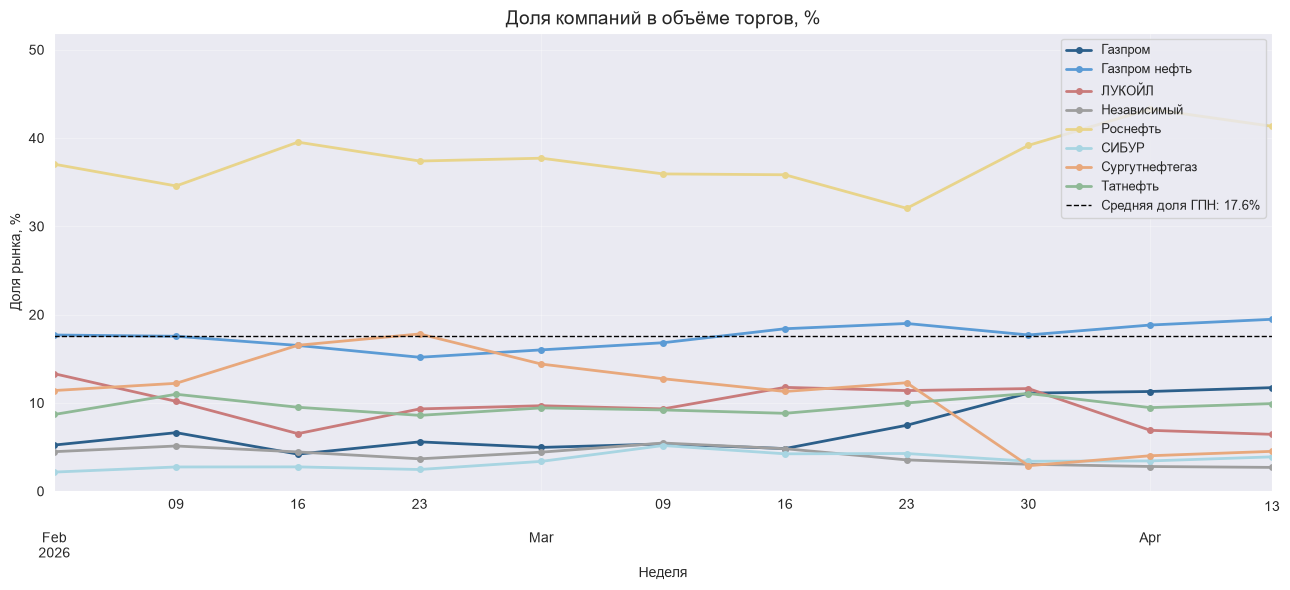

In [109]:
fig2, ax2 = plt.subplots(figsize=(13, 6))

weekly_share.plot(
    ax=ax2, 
    marker='o', 
    color=colors, 
    linewidth=2,
    markersize=4,
    legend=True
)

# Средняя линия Газпром нефти
gpn_mean = weekly_share['Газпром нефть'].mean()
ax2.axhline(
    gpn_mean, 
    color='black', 
    ls='--', 
    lw=1,
    label=f'Средняя доля ГПН: {gpn_mean:.1f}%'
)

ax2.set_title('Доля компаний в объёме торгов, %', fontsize=14)
ax2.set_ylabel('Доля рынка, %')
ax2.set_ylim(0, max(weekly_share['Роснефть'].max() * 1.2, 5))
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

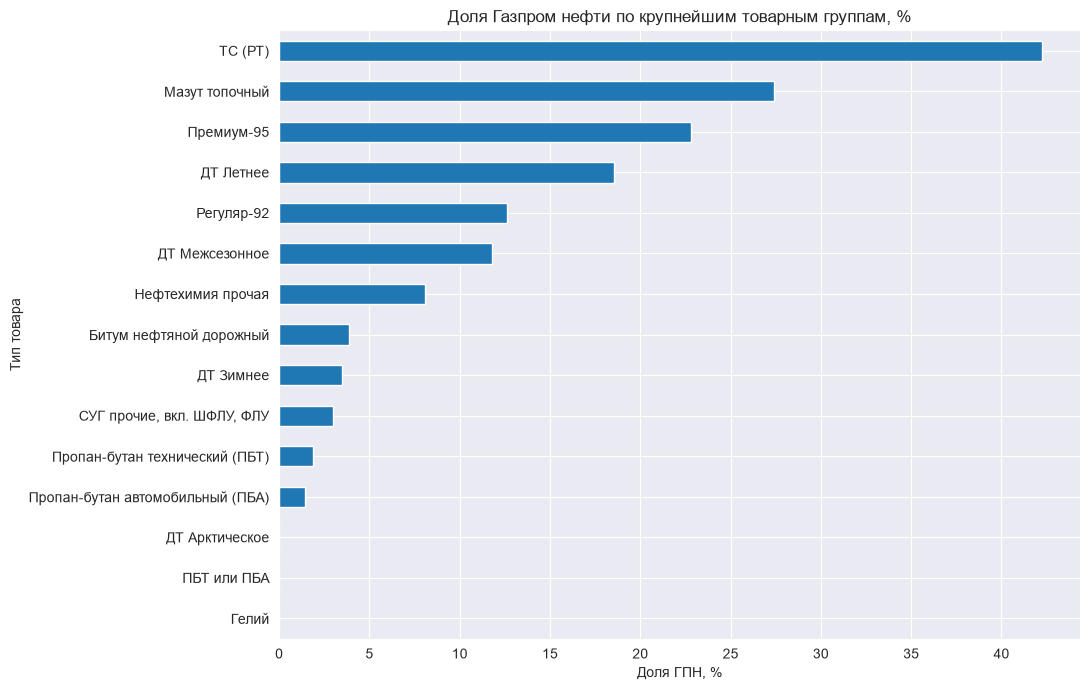

,"Объём всего, т","Доля ГПН, %"
Тип товара,,
ДТ Летнее,"2,403,341.0",18.6
Регуляр-92,"1,221,390.0",12.6
Премиум-95,"883,615.0",22.8
ДТ Межсезонное,"734,746.0",11.8
ДТ Зимнее,"699,319.0",3.5
Мазут топочный,"399,255.0",27.4
Пропан-бутан технический (ПБТ),"387,676.0",1.9
Битум нефтяной дорожный,"345,077.0",3.9
ТС (РТ),"276,555.0",42.2


In [129]:
share_by_product = (trades.groupby(['Тип товара', 'Это ГПН'])['Объём (т)'].sum()
                    .unstack(fill_value=0))
share_by_product.columns = ['Конкуренты', 'Газпром нефть']
share_by_product = share_by_product[share_by_product.sum(axis=1) > 0]
share_by_product['Доля ГПН, %'] = (share_by_product['Газпром нефть'] /
                                    share_by_product.sum(axis=1) * 100)
share_by_product['Объём всего, т'] = share_by_product['Газпром нефть'] + share_by_product['Конкуренты']

top_products = share_by_product.sort_values('Объём всего, т', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 7))
top_products.sort_values('Доля ГПН, %')['Доля ГПН, %'].plot.barh(ax=ax, color='#1f77b4')
ax.set_title('Доля Газпром нефти по крупнейшим товарным группам, %')
ax.set_xlabel('Доля ГПН, %')
plt.tight_layout()
plt.show()

top_products[['Объём всего, т', 'Доля ГПН, %']].sort_values('Объём всего, т', ascending=False)

## Ценовая динамика (VWAP): ГПН vs рынок по сопоставимым продуктам

Сравниваем цены только там, где и ГПН, и конкуренты торгуют одним и тем же товаром

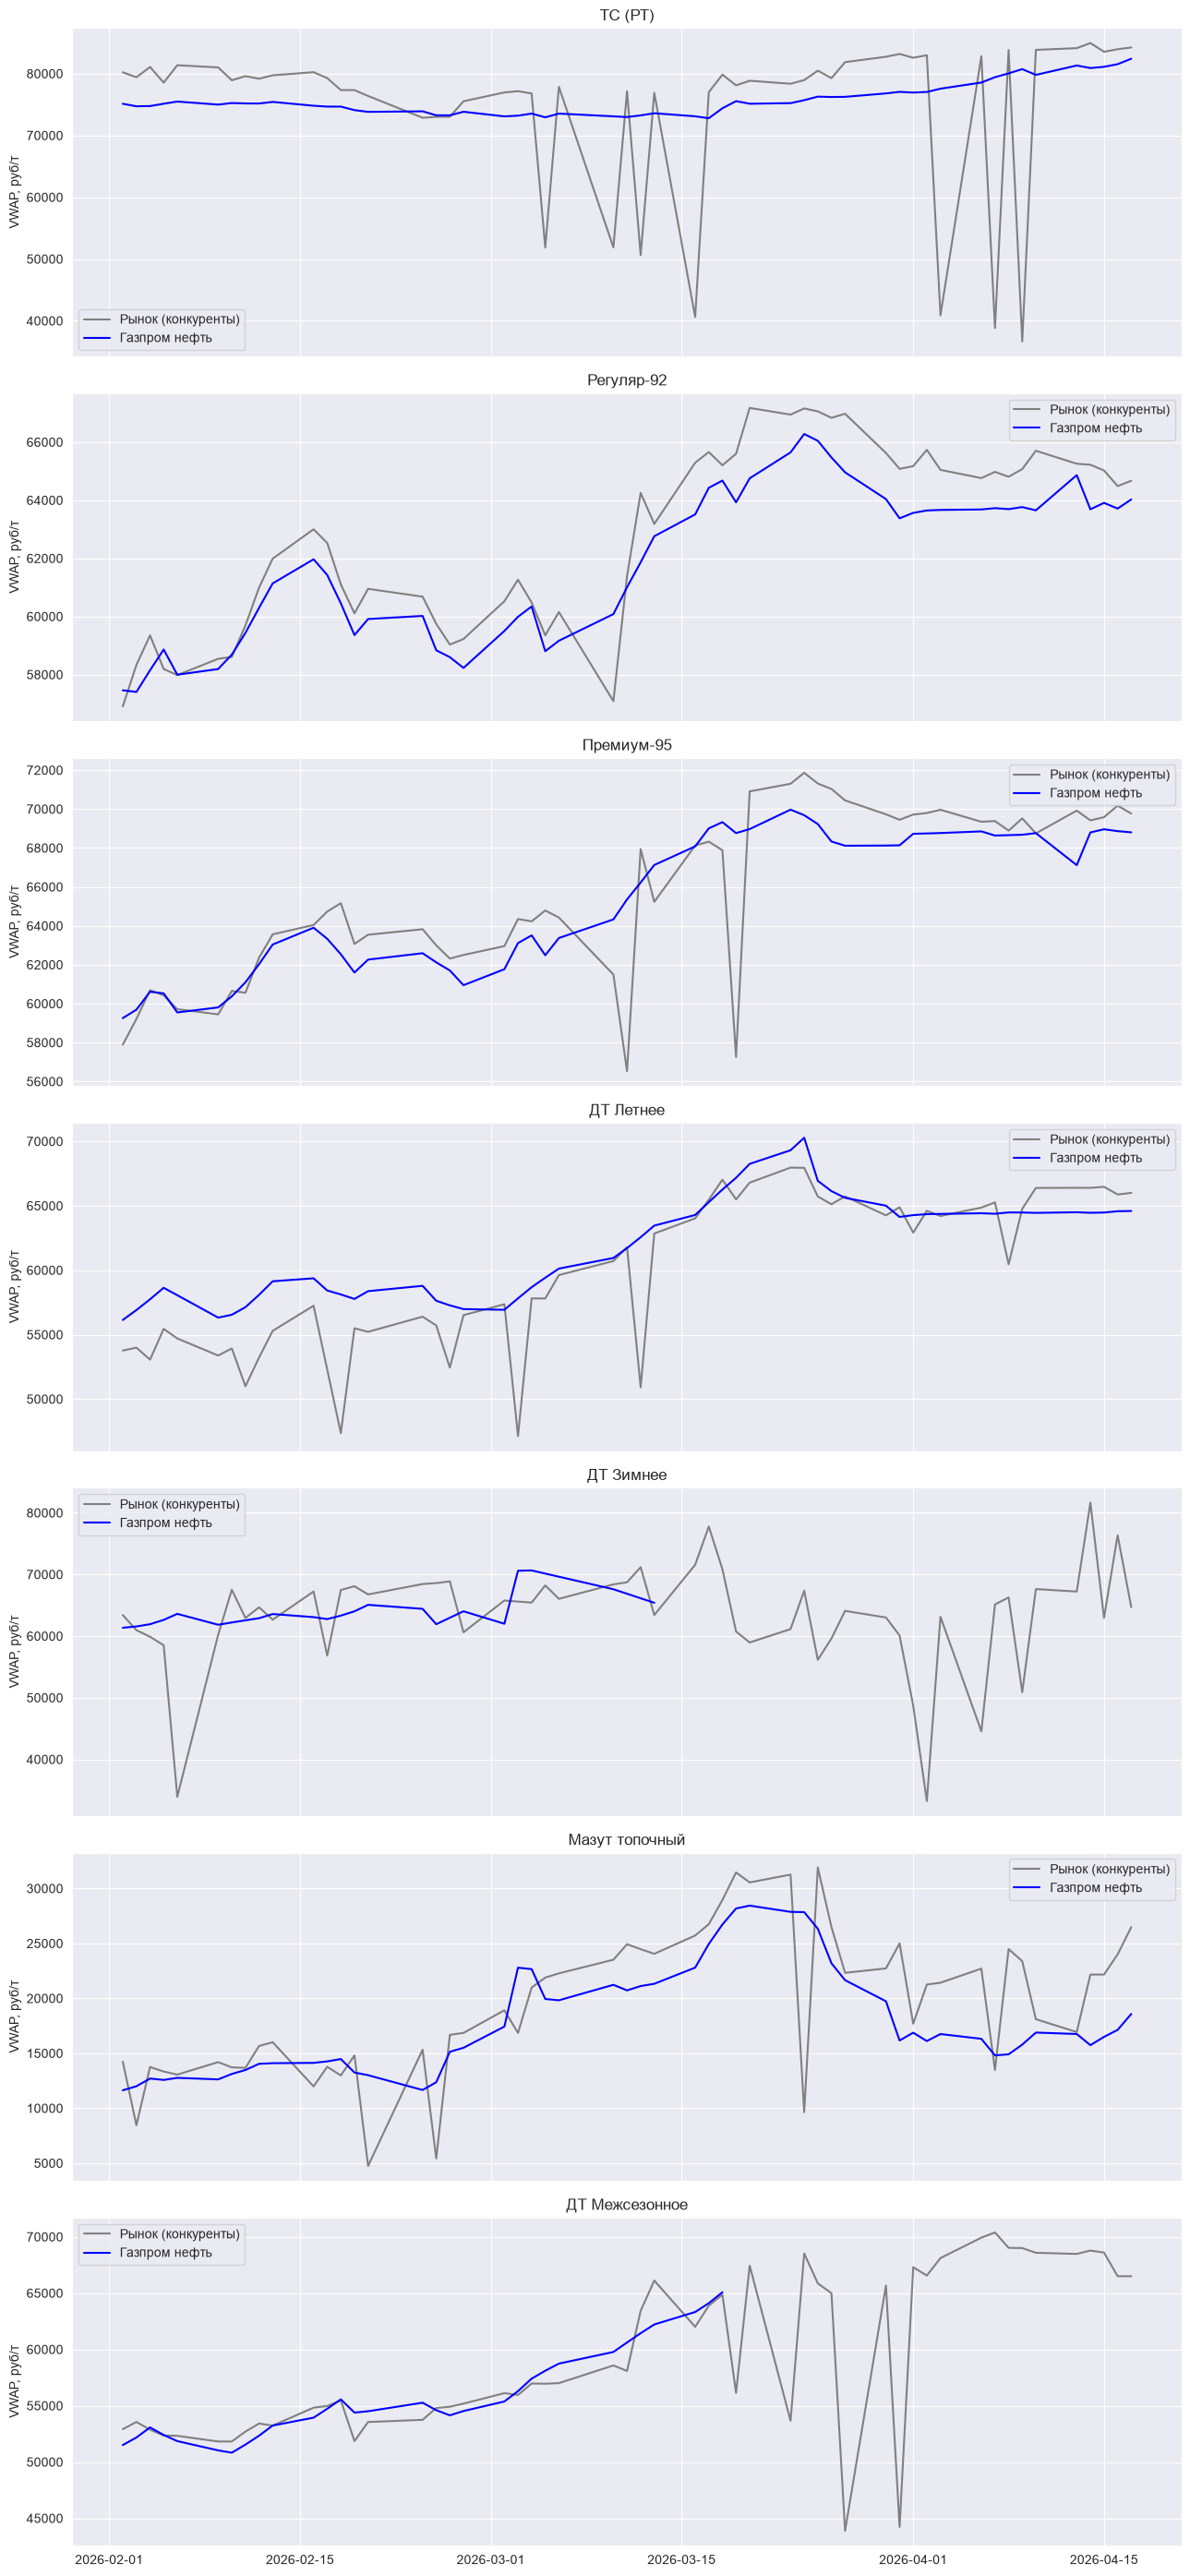

In [137]:
KEY_PRODUCTS = ['ТС (РТ)','Регуляр-92', 'Премиум-95', 'ДТ Летнее', 'ДТ Зимнее', 'Мазут топочный', 'ДТ Межсезонное']

fig, axes = plt.subplots(len(KEY_PRODUCTS), 1, figsize =(13, 4 * len (KEY_PRODUCTS)), sharex = True)


for ax, product in zip(axes, KEY_PRODUCTS):
    sub = trades[trades['Тип товара'] == product]
    if sub.empty:
        continue
    daily_gpn = sub[sub['Это ГПН']].groupby('Дата торгов').apply(
        lambda g: np.average(g['Средневзв. цена VWAP (руб/т)'], weights = g['Объём (т)']))
    daily_market = sub[~sub['Это ГПН']].groupby('Дата торгов').apply(
        lambda g: np.average(g['Средневзв. цена VWAP (руб/т)'], weights = g['Объём (т)']))

    ax.plot(daily_market.index, daily_market.values, label='Рынок (конкуренты)', color='grey', lw=1.5)
    ax.plot(daily_gpn.index, daily_gpn.values, label='Газпром нефть', color='blue', lw=1.5)
    ax.set_title(product)
    ax.set_ylabel('VWAP, руб/т')
    ax.legend()

plt.tight_layout()
plt.show()


In [138]:
rows = []
for product in KEY_PRODUCTS:
    sub = trades[trades['Тип товара'] == product]
    gpn_price = np.average(sub.loc[sub['Это ГПН'], 'Средневзв. цена VWAP (руб/т)'],
                            weights=sub.loc[sub['Это ГПН'], 'Объём (т)']) if sub['Это ГПН'].any() else np.nan
    mkt_price = np.average(sub.loc[~sub['Это ГПН'], 'Средневзв. цена VWAP (руб/т)'],
                            weights=sub.loc[~sub['Это ГПН'], 'Объём (т)']) if (~sub['Это ГПН']).any() else np.nan
    rows.append({'Товар': product, 'VWAP ГПН': gpn_price, 'VWAP рынок': mkt_price,
                 'Разность ГПН, %': (gpn_price / mkt_price - 1) * 100 if mkt_price else np.nan})

pd.DataFrame(rows).set_index('Товар')

,VWAP ГПН,VWAP рынок,"Разность ГПН, %"
Товар,,,
ТС (РТ),"75,859.2","73,246.1",3.6
Регуляр-92,"61,874.1","62,478.2",-1.0
Премиум-95,"65,154.4","65,254.2",-0.2
ДТ Летнее,"62,791.6","62,491.7",0.5
ДТ Зимнее,"62,840.3","62,227.4",1.0
Мазут топочный,"18,223.6","17,870.4",2.0
ДТ Межсезонное,"54,021.4","56,113.8",-3.7


##  Активность торгов: число сделок и средний размер сделки

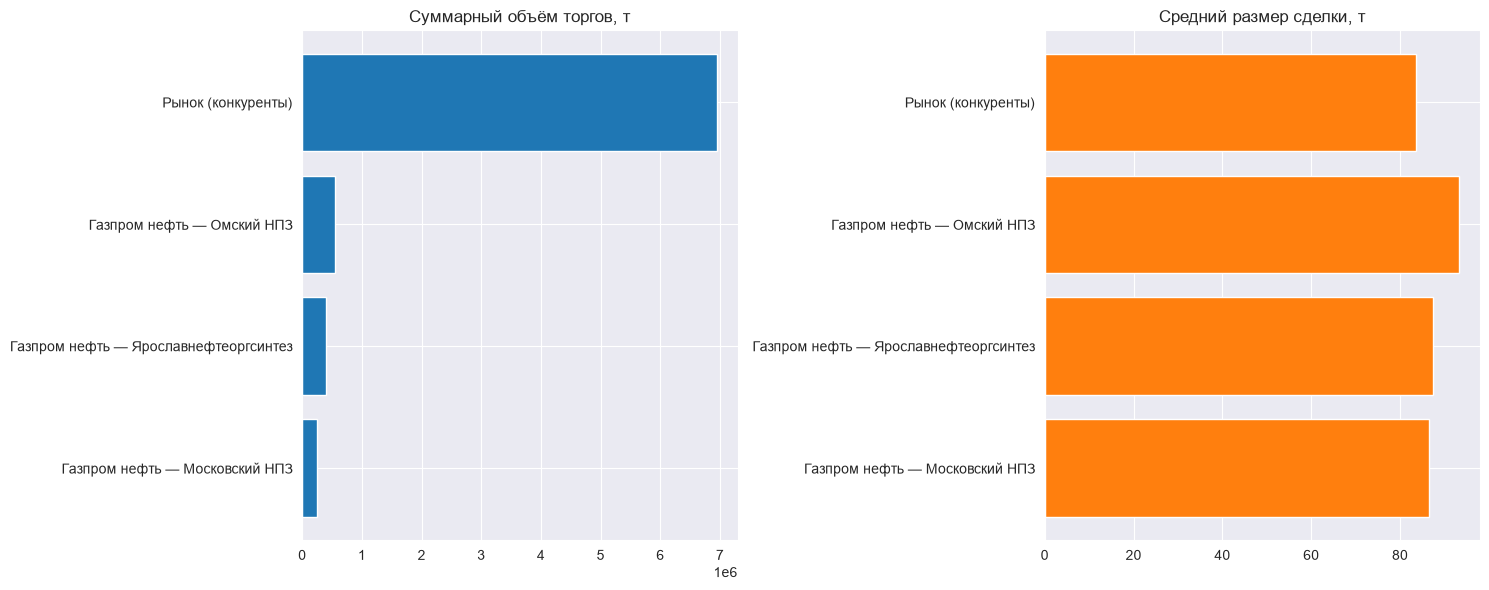

,Группа компании,Объём_т,Число_сделок,"Средний размер сделки, т"
3,Рынок (конкуренты),"6,946,562.0","83,018.0",83.7
1,Газпром нефть — Омский НПЗ,"542,119.0","5,808.0",93.3
2,Газпром нефть — Ярославнефтеоргсинтез,"393,637.0","4,504.0",87.4
0,Газпром нефть — Московский НПЗ,"245,905.0","2,841.0",86.6


In [120]:
activity = trades.groupby('Группа компании').agg(
    Объём_т=('Объём (т)', 'sum'),
    Число_сделок=('Число сделок', 'sum'),
).reset_index()
activity['Средний размер сделки, т'] = activity['Объём_т'] / activity['Число_сделок']
activity = activity.sort_values('Объём_т', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(activity['Группа компании'], activity['Объём_т'], color='#1f77b4')
axes[0].set_title('Суммарный объём торгов, т')
axes[0].invert_yaxis()

axes[1].barh(activity['Группа компании'], activity['Средний размер сделки, т'], color='#ff7f0e')
axes[1].set_title('Средний размер сделки, т')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

activity

## Позиция цены закрытия в 52-недельном диапазоне

`(Цена − Мин.52нед) / (Макс.52нед − Мин.52нед)` — близко к 1 значит цена у верхней границы года,
близко к 0 — у нижней

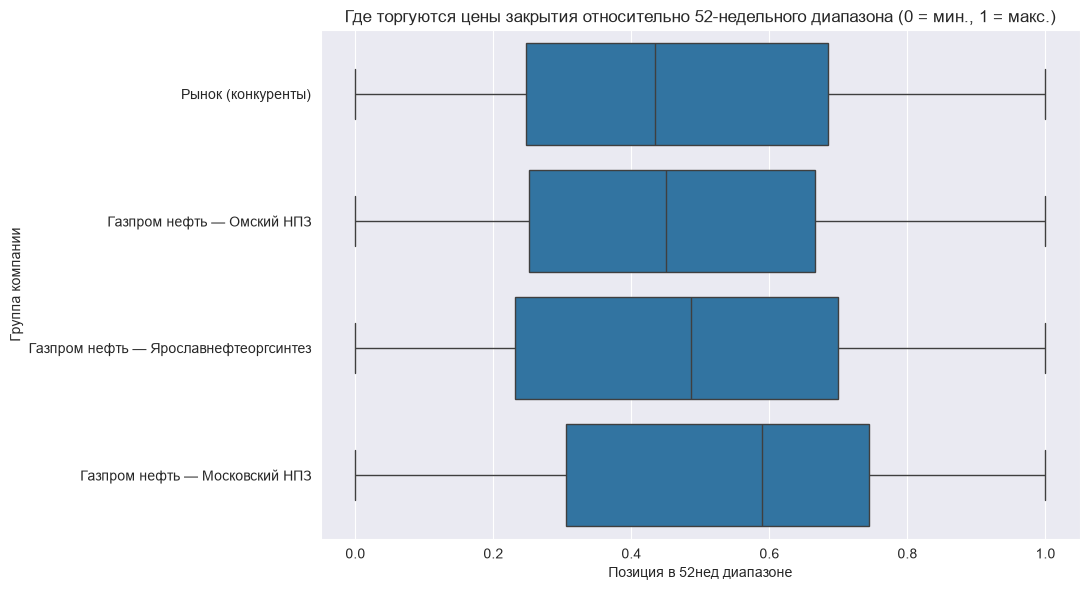

In [128]:
range_df = trades.dropna(subset=['Макс. за 52 нед. (руб/т)', 'Мин. за 52 нед. (руб/т)', 'Цена закрытия (руб/т)']).copy()
range_df = range_df[range_df['Макс. за 52 нед. (руб/т)'] > range_df['Мин. за 52 нед. (руб/т)']]
range_df['Позиция в 52нед диапазоне'] = (
    (range_df['Цена закрытия (руб/т)'] - range_df['Мин. за 52 нед. (руб/т)']) /
    (range_df['Макс. за 52 нед. (руб/т)'] - range_df['Мин. за 52 нед. (руб/т)'])
).clip(0, 1)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=range_df, y='Группа компании', x='Позиция в 52нед диапазоне', ax=ax,
            order=range_df.groupby('Группа компании')['Позиция в 52нед диапазоне'].median().sort_values().index)
ax.set_title('Где торгуются цены закрытия относительно 52-недельного диапазона (0 = мин., 1 = макс.)')
plt.tight_layout()
plt.show()


## Три площадки ГПН между собой: объём, цена, волатильность

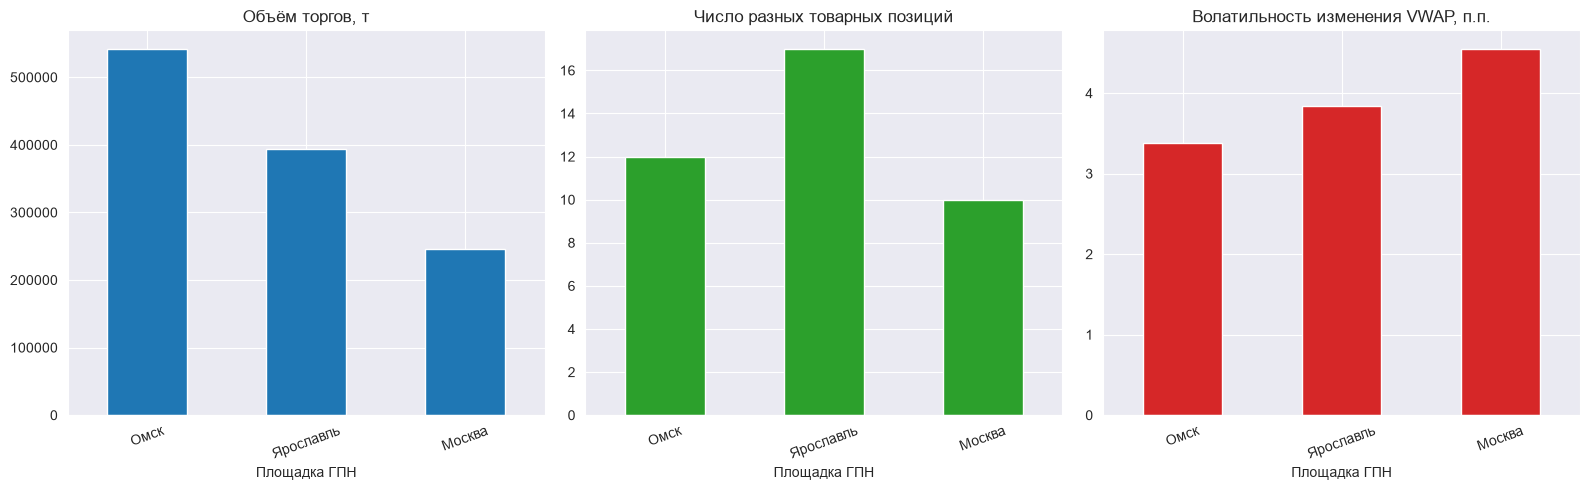

,Объём_т,Число_сделок,Ср_VWAP,Волатильность_изм_VWAP_pct,Число_товарных_позиций
Площадка ГПН,,,,,
Омск,"542,119.0","5,808.0","56,788.9",3.4,12
Ярославль,"393,637.0","4,504.0","58,380.5",3.8,17
Москва,"245,905.0","2,841.0","46,615.0",4.5,10


In [133]:
gpn_trades = trades[trades['Это ГПН']]

gpn_compare = gpn_trades.groupby('Площадка ГПН').agg(
    Объём_т=('Объём (т)', 'sum'),
    Число_сделок=('Число сделок', 'sum'),
    Ср_VWAP=('Средневзв. цена VWAP (руб/т)', 'mean'),
    Волатильность_изм_VWAP_pct=('Изм. VWAP (%)', 'std'),
    Число_товарных_позиций=('Тип товара', 'nunique'),
).sort_values('Объём_т', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
gpn_compare['Объём_т'].plot.bar(ax=axes[0], color='#1f77b4', rot=20)
axes[0].set_title('Объём торгов, т')
gpn_compare['Число_товарных_позиций'].plot.bar(ax=axes[1], color='#2ca02c', rot=20)
axes[1].set_title('Число разных товарных позиций')
gpn_compare['Волатильность_изм_VWAP_pct'].plot.bar(ax=axes[2], color='#d62728', rot=20)
axes[2].set_title('Волатильность изменения VWAP, п.п.')
plt.tight_layout()
plt.show()

gpn_compare

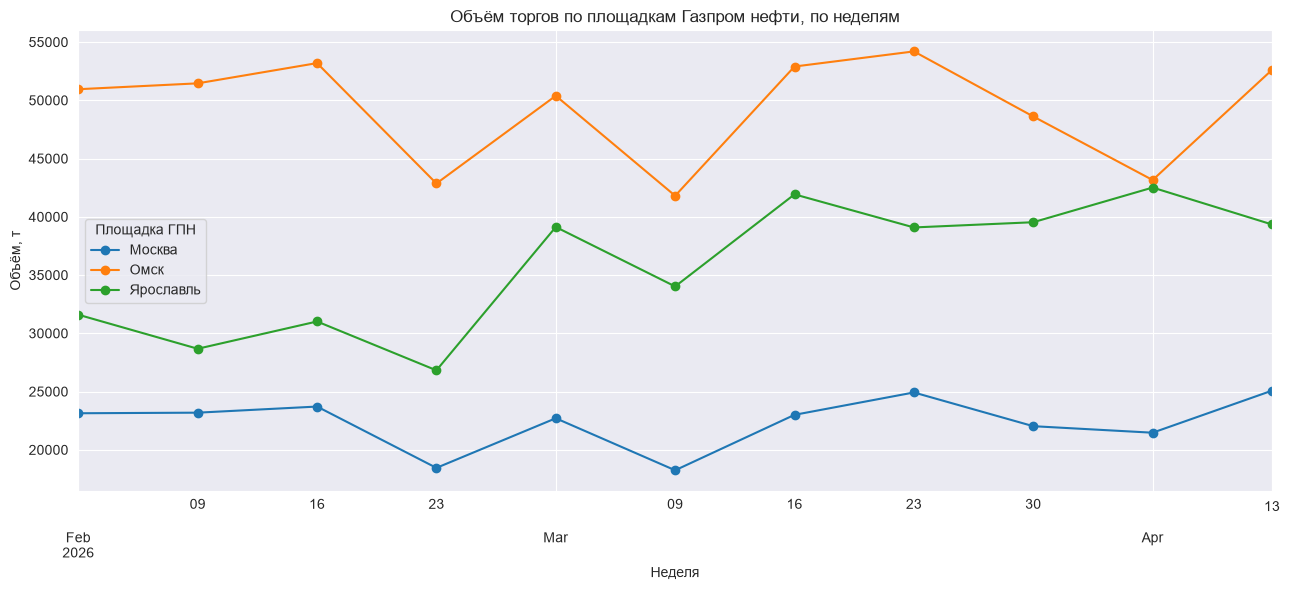

In [134]:
# Динамика объёма трёх площадок ГПН по неделям
gpn_weekly = gpn_trades.groupby(['Неделя', 'Площадка ГПН'])['Объём (т)'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6))
gpn_weekly.plot(ax=ax, marker='o')
ax.set_title('Объём торгов по площадкам Газпром нефти, по неделям')
ax.set_ylabel('Объём, т')
plt.tight_layout()
plt.show()